In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/Datasets/OS Collected Data"

print("Classes:", os.listdir(DATASET_PATH))



Classes: ['Osteoporosis', 'Osteopenia', 'Normal']


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


In [ ]:
data = []

for label in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, label)
    for img in os.listdir(folder_path):
        data.append([os.path.join(folder_path, img), label])

df = pd.DataFrame(data, columns=["filepath", "label"])

print("Total Images:", len(df))
print(df["label"].value_counts())


Total Images: 1947
label
Osteoporosis    793
Normal          780
Osteopenia      374
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train Distribution:")
print(train_df["label"].value_counts())

print("\nValidation Distribution:")
print(val_df["label"].value_counts())

print("\nTest Distribution:")
print(test_df["label"].value_counts())


Train Distribution:
label
Osteoporosis    555
Normal          546
Osteopenia      261
Name: count, dtype: int64

Validation Distribution:
label
Osteoporosis    119
Normal          117
Osteopenia       56
Name: count, dtype: int64

Test Distribution:
label
Osteoporosis    119
Normal          117
Osteopenia       57
Name: count, dtype: int64


In [ ]:
train_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
).flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

val_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
).flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_gen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
).flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 1362 validated image filenames belonging to 3 classes.
Found 292 validated image filenames belonging to 3 classes.
Found 293 validated image filenames belonging to 3 classes.


In [ ]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(0.8315018315018315), 1: np.float64(1.739463601532567), 2: np.float64(0.818018018018018)}


In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation="softmax")
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)




Epoch 1/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 738s 16s/step - accuracy: 0.6043 - loss: 0.8167 - val_accuracy: 0.6884 - val_loss: 0.7184 - learning_rate: 1.0000e-04
Epoch 2/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.7085 - loss: 0.6189 - val_accuracy: 0.7021 - val_loss: 0.6291 - learning_rate: 1.0000e-04
Epoch 3/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.7327 - loss: 0.5715 - val_accuracy: 0.7089 - val_loss: 0.5753 - learning_rate: 1.0000e-04
Epoch 4/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7438 - loss: 0.5381 - val_accuracy: 0.7534 - val_loss: 0.5888 - learning_rate: 1.0000e-04
Epoch 5/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.7680 - loss: 0.5173 - val_accuracy: 0.7603 - val_loss: 0.5377 - learning_rate: 1.0000e-04
Epoch 6/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7577 - loss: 0.5090 - val_accuracy: 0.7637 - val_loss: 0.5543 - learning_rate: 1.0000e-04
Epoch 7/25
43/43 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.7731 - los

In [ ]:
test_gen.reset()
preds = model.predict(test_gen)
pred_classes = np.argmax(preds, axis=1)

true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_labels))


10/10 ━━━━━━━━━━━━━━━━━━━━ 120s 13s/step
              precision    recall  f1-score   support

      Normal       0.98      0.75      0.85       117
  Osteopenia       0.71      0.79      0.75        57
Osteoporosis       0.75      0.88      0.81       119

    accuracy                           0.81       293
   macro avg       0.81      0.81      0.80       293
weighted avg       0.83      0.81      0.81       293



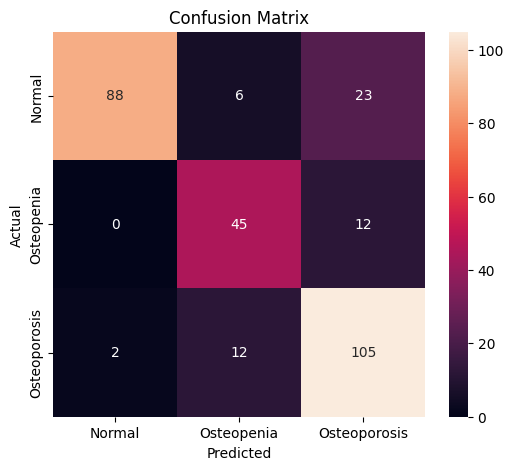

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 847ms/step


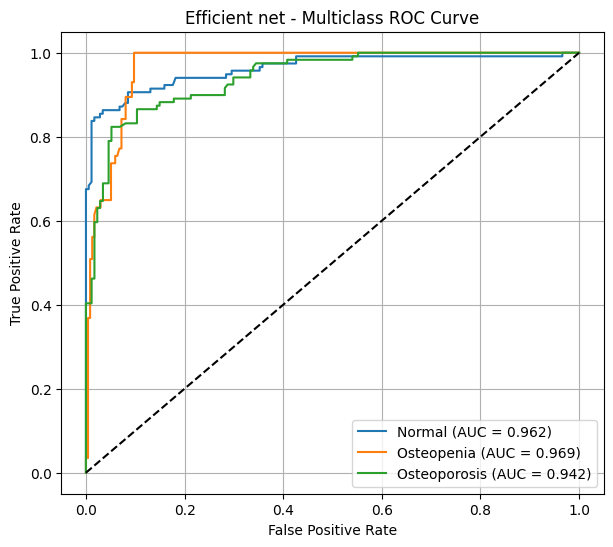

In [ ]:
test_gen.reset()

pred_probs = model.predict(test_gen)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())
from sklearn.preprocessing import label_binarize

n_classes = len(class_labels)

true_binary = label_binarize(true_classes, classes=range(n_classes))
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_binary[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Efficient net - Multiclass ROC Curve")
plt.legend()
plt.grid(True)
plt.show()




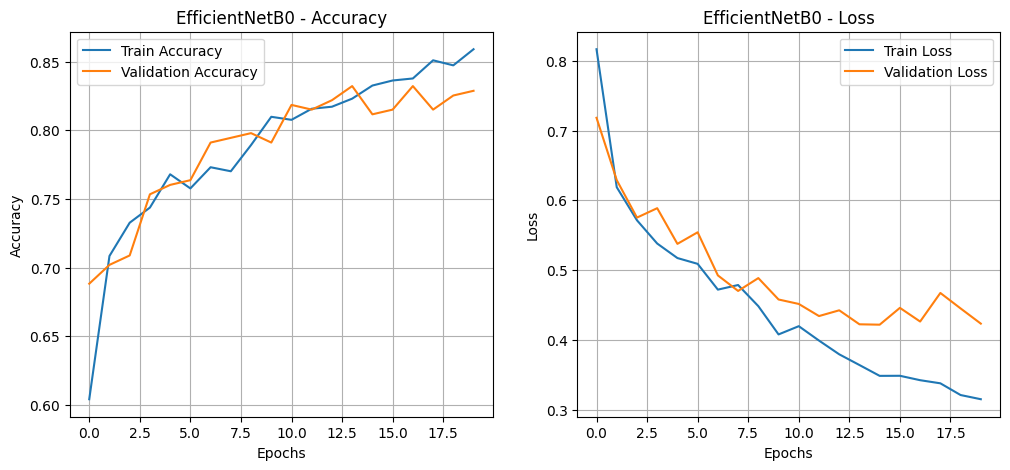

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('EfficientNetB0 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('EfficientNetB0 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
os.makedirs("/content/drive/MyDrive/multi_Saved_Models", exist_ok=True)
print("✅ Model save folder ready")


✅ Model save folder ready


In [ ]:
model.save("/content/drive/MyDrive/multi_Saved_Models/efficientnet_model.keras")
print("✅ EfficientNet model saved")



✅ EfficientNet model saved


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
batch_size = 16
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_resnet = train_datagen_resnet.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",   # 🔥 CHANGED
    shuffle=True
)

val_gen_resnet = val_test_datagen_resnet.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",   # 🔥 CHANGED
    shuffle=False
)

test_gen_resnet = val_test_datagen_resnet.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",   # 🔥 CHANGED
    shuffle=False
)


Found 1362 validated image filenames belonging to 3 classes.
Found 292 validated image filenames belonging to 3 classes.
Found 293 validated image filenames belonging to 3 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model_resnet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(3, activation="softmax")   # 🔥 CHANGED
])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 104s 918ms/step - accuracy: 0.6072 - loss: 0.8272 - val_accuracy: 0.6986 - val_loss: 0.7042 - learning_rate: 3.0000e-05
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 737ms/step - accuracy: 0.6968 - loss: 0.6379 - val_accuracy: 0.7295 - val_loss: 0.6081 - learning_rate: 3.0000e-05
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 725ms/step - accuracy: 0.7298 - loss: 0.5801 - val_accuracy: 0.7637 - val_loss: 0.5577 - learning_rate: 3.0000e-05
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 741ms/step - accuracy: 0.7298 - loss: 0.5412 - val_accuracy: 0.7911 - val_loss: 0.5304 - learning_rate: 3.0000e-05
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 734ms/step - accuracy: 0.7526 - loss: 0.5186 - val_accuracy: 0.7774 - val_loss: 0.5760 - learning_rate: 3.0000e-05
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 727ms/step - accuracy: 0.7673 - loss: 0.4852 - val_accuracy: 0.7774 - val_loss: 0.5244 - learning_rate: 3.0000e-05
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 732ms/step - ac

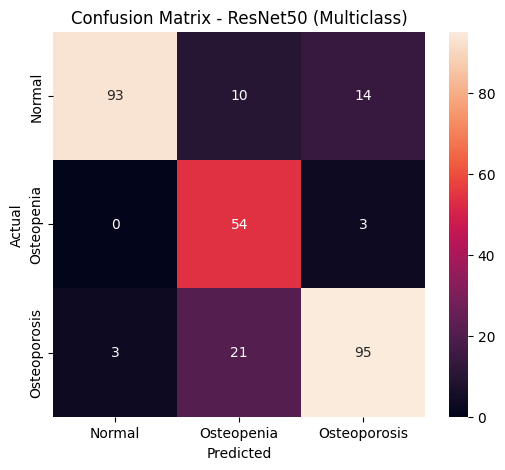

Multiclass ROC-AUC: 0.9563051097909997


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="categorical_crossentropy",   # 🔥 CHANGED
    metrics=["accuracy"]
)
history_resnet = model_resnet.fit(
    train_gen_resnet,
    epochs=30,
    validation_data=val_gen_resnet,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen_resnet.reset()

pred_probs = model_resnet.predict(test_gen_resnet)
pred_classes = np.argmax(pred_probs, axis=1)   # 🔥 CHANGED

true_classes = test_gen_resnet.classes
class_labels = list(test_gen_resnet.class_indices.keys())

# Classification Report
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50 (Multiclass)")
plt.show()
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_bin = label_binarize(true_classes, classes=[0,1,2])

auc_score = roc_auc_score(
    y_true_bin,
    pred_probs,
    multi_class="ovr"
)

print("Multiclass ROC-AUC:", auc_score)




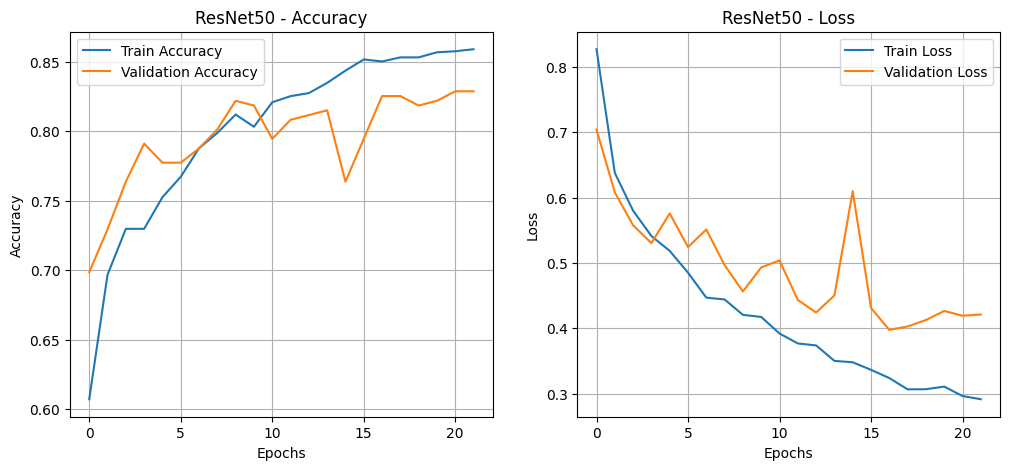

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model_resnet.save("/content/drive/MyDrive/multi_Saved_Models/resnet_model.keras")
print("✅ resNet model saved")



✅ resNet model saved


19/19 ━━━━━━━━━━━━━━━━━━━━ 8s 437ms/step


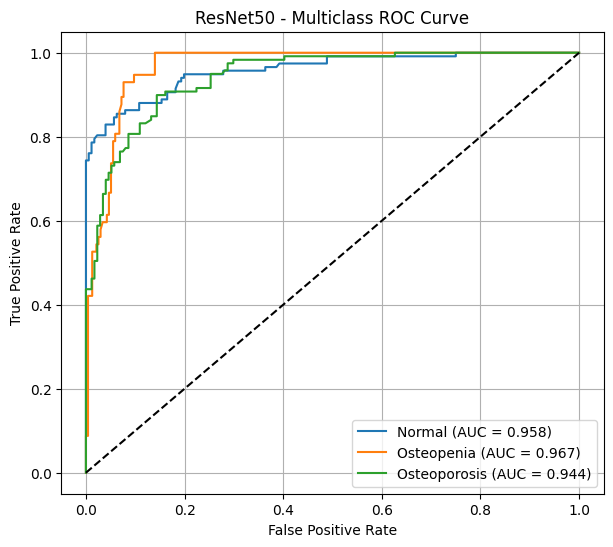

In [ ]:
test_gen_resnet.reset()

pred_probs = model_resnet.predict(test_gen_resnet)
true_classes = test_gen_resnet.classes
class_labels = list(test_gen_resnet.class_indices.keys())
from sklearn.preprocessing import label_binarize

n_classes = len(class_labels)

true_binary = label_binarize(true_classes, classes=range(n_classes))
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_binary[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 - Multiclass ROC Curve")
plt.legend()
plt.grid(True)
plt.show()




Found 1362 validated image filenames belonging to 3 classes.
Found 292 validated image filenames belonging to 3 classes.
Found 293 validated image filenames belonging to 3 classes.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.5712 - loss: 0.9082 - val_accuracy: 0.6952 - val_loss: 0.6913 - learning_rate: 3.0000e-05
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 741ms/step - accuracy: 0.6887 - loss: 0.6909 - val_accuracy: 0.6986 - val_loss: 0.6338 - learning_rate: 3.0000e-05
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 66s 764ms/step - accuracy: 0.6990 - loss: 0.6232 - val_accuracy: 0.6952 - val_loss: 0.6645 - learning_rate: 3.0000e-05
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 63s 731ms/step - accuracy: 0.7093 - loss: 0.5964 - val_accuracy: 0.7055 - val_loss: 0.6558 - learning_rate: 9.0000e-06
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 62s 719ms/step - accuracy: 0.7188 - loss: 0.5808 - val_accuracy: 0.7192 - val_loss: 0.6251 - learning_ra

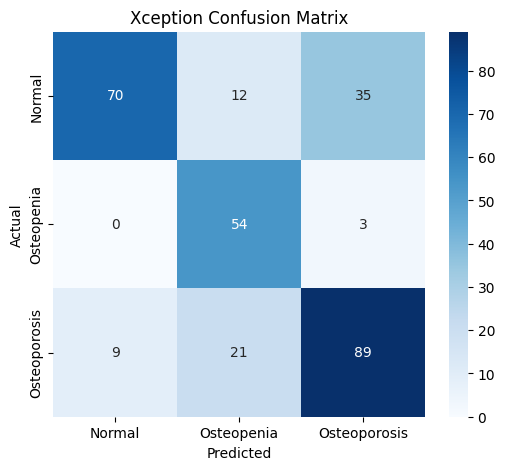

Xception ROC-AUC: 0.8656589620604338


In [ ]:
# ======================================
# XCEPTION - MULTICLASS (3 CLASSES)
# ======================================

from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications import Xception

# -------------------------
# Data Generators
# -------------------------

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    shuffle=False
)

# -------------------------
# Model
# -------------------------

base_model = Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model_xception = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(3, activation="softmax")
])

model_xception.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_xception = model_xception.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

model_xception.save("/content/drive/MyDrive/multi_Saved_Models/xception_model.keras")
print("✅ Xception model saved")

# ==============================
# XCEPTION EVALUATION
# ==============================

print("\n🔵 Xception Evaluation\n")

# Create test generator (same as others)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

# Predictions
pred_probs = model_xception.predict(test_gen)
pred_classes = np.argmax(pred_probs, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_gen.classes, pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(test_gen.classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cmap='Blues')
plt.title("Xception Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC-AUC (OVR)
y_true_bin = label_binarize(test_gen.classes, classes=[0,1,2])
roc_auc = roc_auc_score(y_true_bin, pred_probs, multi_class='ovr')
print("Xception ROC-AUC:", roc_auc)

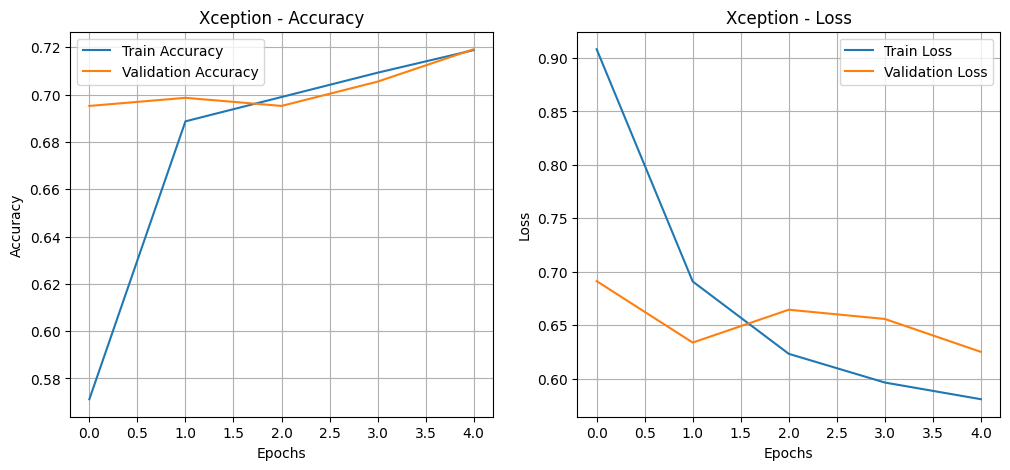

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_xception.history['accuracy'], label='Train Accuracy')
plt.plot(history_xception.history['val_accuracy'], label='Validation Accuracy')
plt.title('Xception - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_xception.history['loss'], label='Train Loss')
plt.plot(history_xception.history['val_loss'], label='Validation Loss')
plt.title('Xception - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Class Weights: {0: np.float64(0.8315018315018315), 1: np.float64(1.739463601532567), 2: np.float64(0.818018018018018)}
Found 1362 validated image filenames belonging to 3 classes.
Found 292 validated image filenames belonging to 3 classes.
Found 293 validated image filenames belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5609 - loss: 0.9605 - val_accuracy: 0.5925 - val_loss: 0.9233 - learning_rate: 3.0000e-05
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 61s 702ms/step - accuracy: 0.6615 - loss: 0.7481 - val_accuracy: 0.6610 - val_loss: 0.8306 - learning_rate: 3.0000e-05
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 58s 679ms/step - accuracy: 0.6836 - loss: 0.6702 - val_accuracy: 0.6815 - val_loss: 0.7728 - learning_rate: 3.0000e-05
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 759ms/step - accuracy: 0.6865 - loss: 0.6525 - val_accuracy: 0.6986 - val_loss: 0.7377 - learning_rate: 3.0000e-05
Epoch 5/30
86/86 ━━━━━━━━

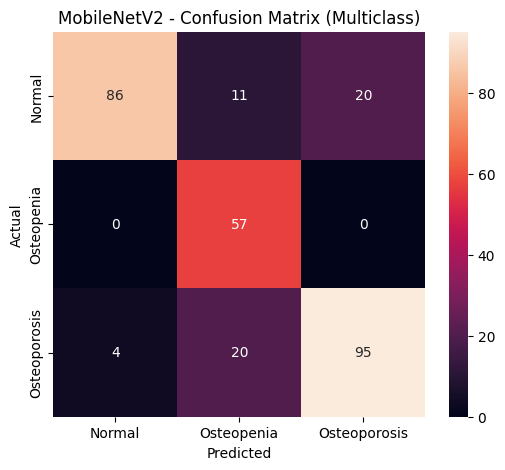

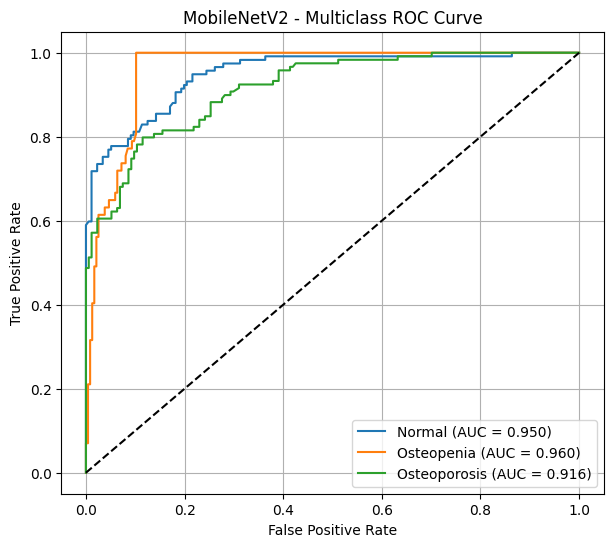

In [ ]:
# ============================
# MOBILE NET V2 - MULTICLASS
# ============================

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
batch_size=16
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# ---------------------------
# Data Generators
# ---------------------------

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# ---------------------------
# Callbacks
# ---------------------------

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6)

# ---------------------------
# Model
# ---------------------------

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.4),
    Dense(3, activation="softmax")   # 🔥 3 classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ---------------------------
# Training
# ---------------------------

history_mobilenet = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

# ---------------------------
# Evaluation
# ---------------------------

test_gen.reset()
pred_probs = model.predict(test_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification Report
print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# ---------------------------
# Confusion Matrix
# ---------------------------

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 - Confusion Matrix (Multiclass)")
plt.show()



# ---------------------------
# Multiclass ROC Curve
# ---------------------------

n_classes = len(class_labels)
true_binary = label_binarize(true_classes, classes=range(n_classes))

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_binary[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 - Multiclass ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


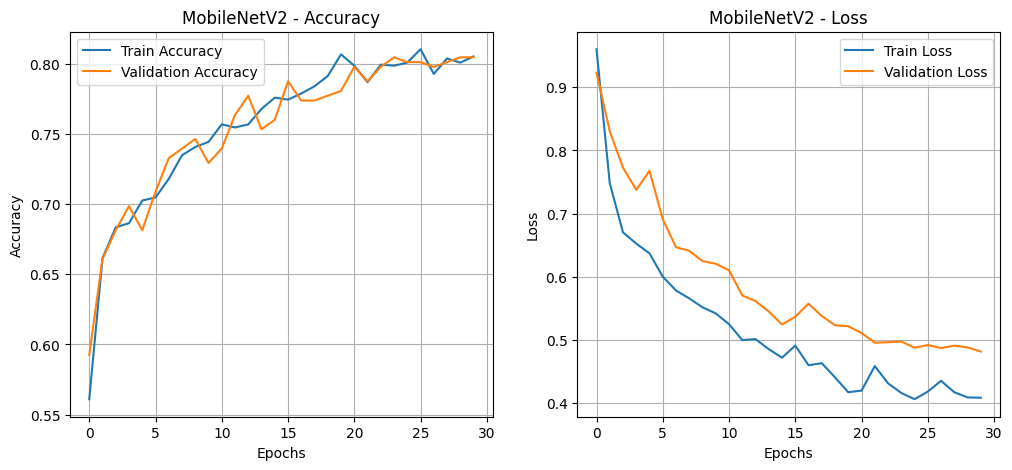

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/multi_Saved_Models/mobilenet_model.keras")
print("✅ mobilenet model saved")



✅ mobilenet model saved


Class Weights: {0: np.float64(0.8315018315018315), 1: np.float64(1.739463601532567), 2: np.float64(0.818018018018018)}
Found 1362 validated image filenames belonging to 3 classes.
Found 292 validated image filenames belonging to 3 classes.
Found 293 validated image filenames belonging to 3 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 844s 10s/step - accuracy: 0.4912 - loss: 1.0344 - val_accuracy: 0.6404 - val_loss: 0.8215 - learning_rate: 3.0000e-05
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 361s 4s/step - accuracy: 0.6035 - loss: 0.8392 - val_accuracy: 0.6644 - val_loss: 0.6931 - learning_rate: 3.0000e-05
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 352s 4s/step - accuracy: 0.6601 - loss: 0.7387 - val_accuracy: 0.6678 - val_loss: 0.6796 - learning_rate: 3.0000e-05
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.6483 - loss: 0.7371 - val_accuracy: 0.6781 - val_loss: 0.6613 - learning_rate: 3.0000e-05
Epoch 5/30
86/86 ━━━━━━━━━━━

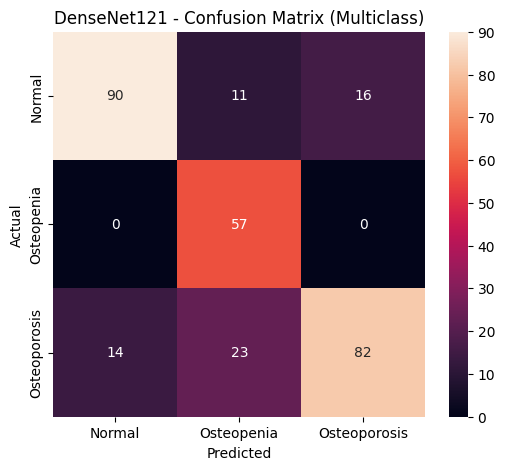

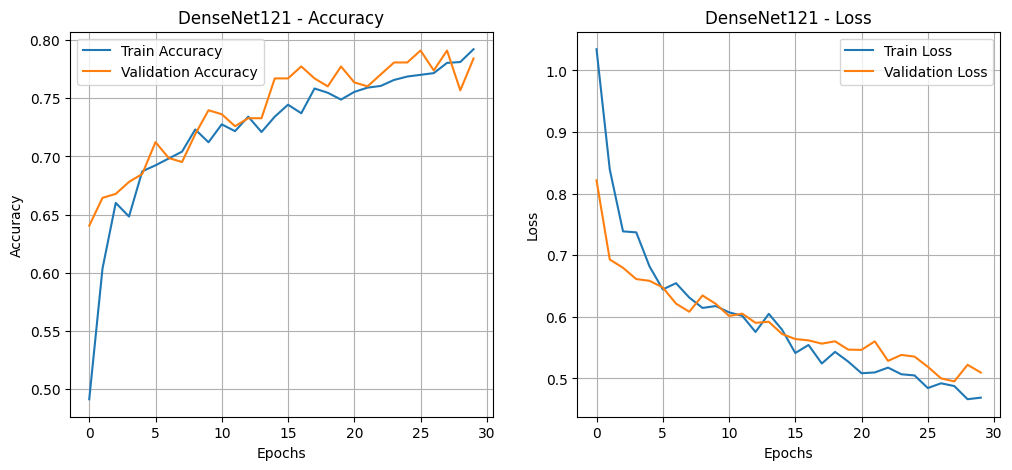

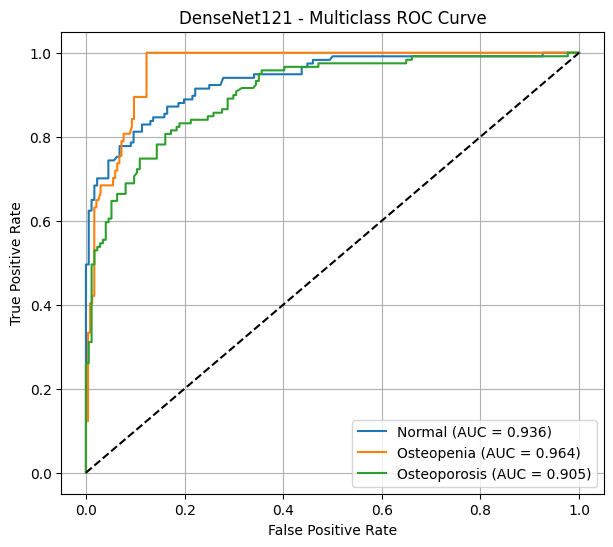

In [ ]:
# ======================================
# DENSENET121 - MULTICLASS (3 CLASSES)
# ======================================

from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
batch_size=16
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# -------------------------
# Data Generators
# -------------------------

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)


# -------------------------
# Callbacks
# -------------------------

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6)

# -------------------------
# Model
# -------------------------

base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers[:-40]:
    layer.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(3, activation="softmax")   # 🔥 3 classes
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------
# Training
# -------------------------

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

# -------------------------
# Evaluation
# -------------------------

test_gen.reset()
pred_probs = model.predict(test_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# -------------------------
# Confusion Matrix
# -------------------------

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DenseNet121 - Confusion Matrix (Multiclass)")
plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet121 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('DenseNet121 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# -------------------------
# Multiclass ROC Curve
# -------------------------

n_classes = len(class_labels)
true_binary = label_binarize(true_classes, classes=range(n_classes))

plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(true_binary[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet121 - Multiclass ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.save("/content/drive/MyDrive/multi_Saved_Models/densenet_model.keras")
print("✅ densenet model saved")



✅ densenet model saved


In [ ]:
from tensorflow.keras.models import load_model

efficientnet_model = load_model("/content/drive/MyDrive/multi_Saved_Models/efficientnet_model.keras")
resnet_model = load_model("/content/drive/MyDrive/multi_Saved_Models/resnet_model.keras")
mobilenet_model = load_model("/content/drive/MyDrive/multi_Saved_Models/mobilenet_model.keras")
densenet_model = load_model("/content/drive/MyDrive/multi_Saved_Models/densenet_model.keras")
xception_model = load_model("/content/drive/MyDrive/multi_Saved_Models/xception_model.keras")

print("✅ All models loaded successfully")


✅ All models loaded successfully


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras.applications.xception import preprocess_input as xcep_pre

# Store results
model_names = []
accuracies = []
auc_scores = []

# Create a reference test generator (correct label order)
reference_gen = tf.keras.preprocessing.image.ImageDataGenerator().flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

true_numeric = reference_gen.classes
class_labels = list(reference_gen.class_indices.keys())

from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(true_numeric, classes=range(len(class_labels)))


############################################
# FUNCTION TO EVALUATE MODEL
############################################

def evaluate_model(model, preprocess_function, model_name):

    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_function
    )

    test_gen = test_datagen.flow_from_dataframe(
        test_df,
        x_col="filepath",
        y_col="label",
        target_size=(224,224),
        batch_size=32,
        class_mode="categorical",
        shuffle=False
    )

    test_gen.reset()
    pred_probs = model.predict(test_gen)
    pred_classes = np.argmax(pred_probs, axis=1)

    acc = accuracy_score(reference_gen.classes, pred_classes)

    auc_score = roc_auc_score(y_true_bin, pred_probs, multi_class="ovr")

    model_names.append(model_name)
    accuracies.append(acc)
    auc_scores.append(auc_score)

############################################
# EVALUATE ALL MODELS
############################################

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.densenet import preprocess_input as den_pre

evaluate_model(efficientnet_model, eff_pre, "EfficientNetB0")
evaluate_model(resnet_model, res_pre, "ResNet50")
evaluate_model(mobilenet_model, mob_pre, "MobileNetV2")
evaluate_model(densenet_model, den_pre, "DenseNet121")
evaluate_model(xception_model, xcep_pre, "Xception")

############################################
# PRINT RESULTS
############################################

for i in range(len(model_names)):
    print(f"{model_names[i]}")
    print(f"Accuracy : {accuracies[i]:.4f}")
    print(f"ROC-AUC  : {auc_scores[i]:.4f}")
    print("-----------")

best_index = np.argmax(auc_scores)
best_model_name = model_names[best_index]
best_accuracy = accuracies[best_index]
best_auc = auc_scores[best_index]

print("🏆 Best Multiclass Model:", best_model_name)
print("Accuracy:", best_accuracy)
print("ROC-AUC:", best_auc)


Found 293 validated image filenames belonging to 3 classes.
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 239s 22s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 7s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 168s 16s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 72s 7s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 581s 57s/step
EfficientNetB0
Accuracy : 0.8123
ROC-AUC  : 0.9577
-----------
ResNet50
Accuracy : 0.8259
ROC-AUC  : 0.9563
-----------
MobileNetV2
Accuracy : 0.8123
ROC-AUC  : 0.9420
-----------
DenseNet121
Accuracy : 0.7816
ROC-AUC  : 0.9349
-----------
Xception
Accuracy : 0.7270
ROC-AUC  : 0.8657
-----------
🏆 Best Multiclass Model: EfficientNetB0
Accuracy: 0.8122866894197952
ROC-AUC: 0.957665519403796


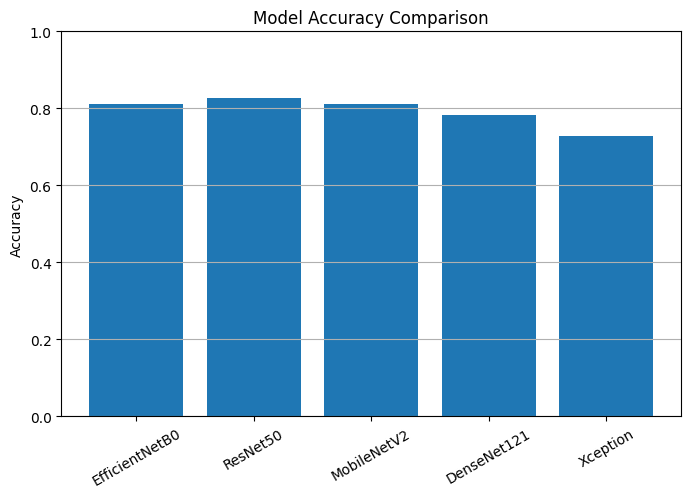

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()


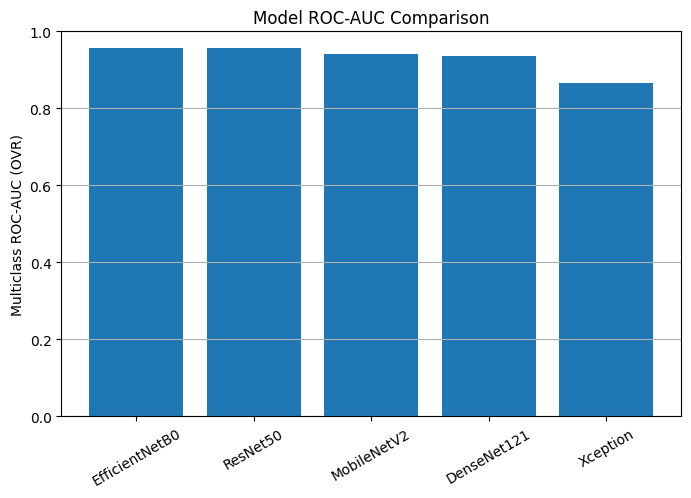

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(model_names, auc_scores)
plt.ylabel("Multiclass ROC-AUC (OVR)")
plt.title("Model ROC-AUC Comparison")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()


Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 225s 22s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 163s 16s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 63s 6s/step
Found 293 validated image filenames belonging to 3 classes.
10/10 ━━━━━━━━━━━━━━━━━━━━ 574s 57s/step


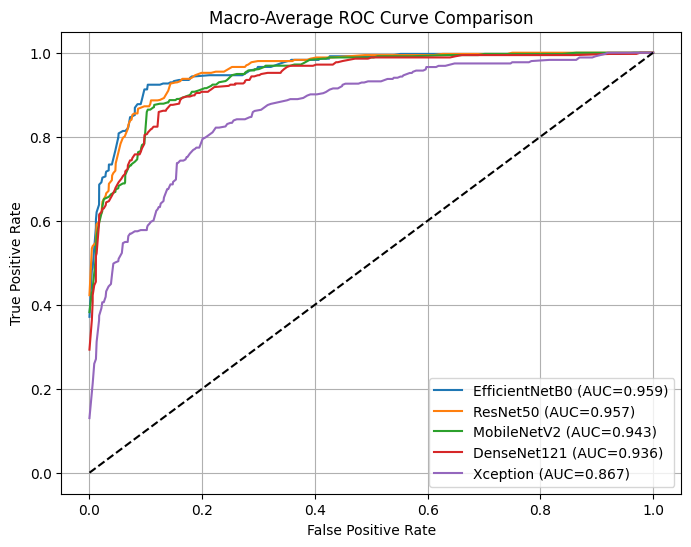

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

def plot_macro_roc(model, preprocess_function, model_name):

    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=preprocess_function
    )

    test_gen = test_datagen.flow_from_dataframe(
        test_df,
        x_col="filepath",
        y_col="label",
        target_size=(224,224),
        batch_size=32,
        class_mode="categorical",
        shuffle=False
    )

    test_gen.reset()
    pred_probs = model.predict(test_gen)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(3):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(3)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(3):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= 3
    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, label=f"{model_name} (AUC={macro_auc:.3f})")

plot_macro_roc(efficientnet_model, eff_pre, "EfficientNetB0")
plot_macro_roc(resnet_model, res_pre, "ResNet50")
plot_macro_roc(mobilenet_model, mob_pre, "MobileNetV2")
plot_macro_roc(densenet_model, den_pre, "DenseNet121")
plot_macro_roc(xception_model, xcep_pre, "Xception")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()
